### 2º MODELO RANDOM FOREST
Con Eda3 que lleva ingieneria de características.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# To save models
import json
import pickle

# Modelado
from sklearn.ensemble import RandomForestClassifier

# Feature Selection
from sklearn.feature_selection import f_classif, SelectKBest

# Métricas
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score
from sklearn.metrics import recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, roc_curve

# Optimizar
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV

# from tqdm import tqdm
import warnings
import zipfile
import os

from utils import get_classifier_metrics

In [2]:
def warn(*args, **kwargs):
    pass

warnings.warn = warn

In [3]:
# Lectura directa desde los archivos
X_train = pd.read_csv('../data/processed/X_train_eda3_obj1.csv')
X_test = pd.read_csv('../data/processed/X_test_eda3_obj1.csv')
y_train = pd.read_csv('../data/processed/y_train_eda3_obj1.csv')
y_test = pd.read_csv('../data/processed/y_test_eda3_obj1.csv')

# Tip: Si el CSV tiene un nombre distinto dentro del zip, 
# pandas suele detectarlo automáticamente si solo hay uno.

In [ ]:
# Eliminar columna de índice sobrante si existe.
for df_temp in [X_train, X_test]:
    if 'Unnamed: 0' in df_temp.columns:
        df_temp.drop(columns=['Unnamed: 0'], inplace=True)

In [ ]:
# 1. Crear una copia de los datos sin el Ticker
X_train_no_ticker = X_train.drop(columns=['Ticker'])
X_test_no_ticker = X_test.drop(columns=['Ticker'])

f'Nuevas dimensiones de entrenamiento: {X_train_no_ticker.shape}'

Nuevas dimensiones de entrenamiento: (490844, 20)


In [ ]:
# Reviso que no haya valores nulos con la nueva carga de archivo.

# Lista de variables cargadas
datasets = {'X_train': X_train,'X_test': X_test,'y_train': y_train, 'y_test': y_test}

for nombre, df_actual in datasets.items():
    if df_actual is not None:
        total_nulos = df_actual.isnull().sum().sum() # Suma total de nulos en todo el dataframe
        print(f'{nombre}: {total_nulos} nulos encontrados.')
        
        # Si hay nulos, mostramos en qué columnas están
        if total_nulos > 0:
            df_actual.isnull().sum()[df_actual.isnull().sum() > 0]
            
    else:
        f'{nombre}: No está cargado (es None).'

X_train: 0 nulos encontrados.
X_test: 0 nulos encontrados.
y_train: 0 nulos encontrados.
y_test: 0 nulos encontrados.


## Entrenamiento del modelo.

In [ ]:
# Definir los hiperparámetros
hparam_foreclas = {'n_estimators': [50, 100, 200],
                   'max_depth': [3, 5, 10],
                   'min_samples_leaf': [100, 150, 200]}

# Configuración del modelo y búsqueda
tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=18, class_weight='balanced'),
                           param_grid=hparam_foreclas,
                           cv=tscv,
                           scoring='roc_auc',
                           n_jobs=-1,
                           verbose=1)

# Entrenar con datos escalados. (se escalan en el eda)
grid_search.fit(X_train, y_train)

# Extraer el mejor modelo
best_rf = grid_search.best_estimator_

f'Mejor modelo encontrado:', grid_search.best_params_

Fitting 5 folds for each of 27 candidates, totalling 135 fits


c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Mejor modelo encontrado: {'max_depth': 10, 'min_samples_leaf': 100, 'n_estimators': 200}


In [ ]:
# Usar los mejores parámetros
model_sin_ticker = RandomForestClassifier(n_estimators=grid_search.best_params_['n_estimators'],
                                          max_depth=grid_search.best_params_['max_depth'],
                                          min_samples_leaf=grid_search.best_params_['min_samples_leaf'],
                                          class_weight='balanced',
                                          random_state=18,
                                          n_jobs=-1)

# Entrenar
model_sin_ticker.fit(X_train_no_ticker, y_train)

# Predecir
y_pred_no_ticker = model_sin_ticker.predict(X_test_no_ticker)
y_probs_no_ticker = model_sin_ticker.predict_proba(X_test_no_ticker)[:, 1]

# Reporte sin Ticker
classification_report(y_test, y_pred_no_ticker)

c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



--- REPORTE SIN TICKER ---
              precision    recall  f1-score   support

           0       0.50      0.40      0.44     59238
           1       0.53      0.63      0.58     63474

    accuracy                           0.52    122712
   macro avg       0.52      0.52      0.51    122712
weighted avg       0.52      0.52      0.51    122712



Top 15 variables más importantes:
           Variable  Importancia
18       retorno_5d     0.113162
8      Price_Change     0.103373
9      Volume_Ratio     0.079560
15        RSI_lag_1     0.063820
6       BB_Position     0.061742
5               RSI     0.054350
19  volatilidad_10d     0.041847
11     Volume_lag_2     0.041116
10     Volume_lag_1     0.038963
4       MACD_Signal     0.038535
16       MACD_lag_1     0.037607
13     Volume_lag_5     0.037589
0             Close     0.037439
14    Volume_lag_10     0.036752
2            EMA_12     0.036499


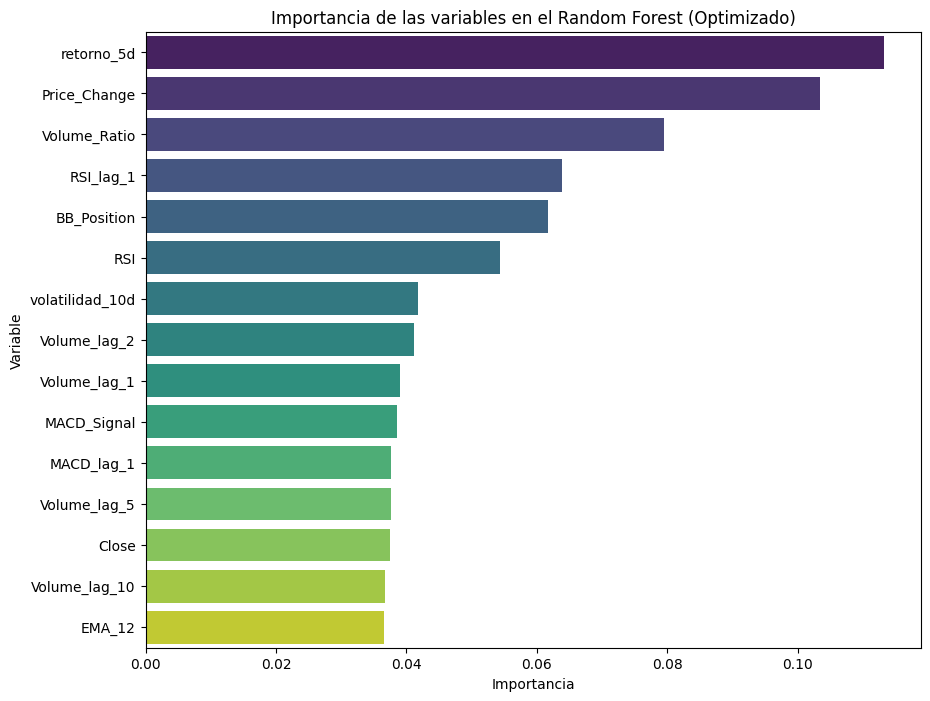

In [ ]:
# Extraer importancia de las variables del mejor modelo
importancias = pd.DataFrame({'Variable': X_train_no_ticker.columns,
                             'Importancia': model_sin_ticker.feature_importances_}).sort_values(by='Importancia', ascending=False)

# Top 15 variables más importantes:
importancias.head(15)

In [ ]:
# Graficar las 15 primeras para tener una mejor visión
plt.figure(figsize=(10, 8))
sns.barplot(x='Importancia', y='Variable', data=importancias.head(15), palette='viridis')
plt.title('Importancia de las variables en el Random Forest (Optimizado)')
plt.show()

## ¿Qué buscar en los resultados?
- Caso A: La Precision de la Clase 1 sube o se mantiene (~0.53):
Significado: ¡Excelente! El modelo es capaz de encontrar patrones de mercado sin saber qué acción está mirando. Este es un modelo mucho más robusto para el futuro.

- Caso B: La Precision cae al 0.50:
Significado: Malas noticias. El modelo no sabe leer el RSI ni la Volatilidad de forma útil todavía. Necesitas indicadores más agresivos (como el volumen relativo o la distancia a medias móviles) o datos de mayor calidad.

### Resultado:
Como vemos que la precisión de la clase 1. está en el 53% podemos decir que hemos mejorado el modelo quitando la columna 'Ticker'


## Análisis de lo que esto significa para el proyecto:

1. La 'Prueba del Algodón': Tu modelo es real
Si el modelo hubiera bajado al 50% (puro azar) al quitar el Ticker, sabríamos que el modelo era un 'fraude' que solo memorizaba nombres. Al mantenerse en el 0.52, has demostrado que tus indicadores técnicos (RSI, Volatilidad, etc.) tienen una ventaja estadística real, aunque sea pequeña. El modelo está encontrando patrones en el comportamiento del precio que son universales para cualquier acción.

2. Análisis del Reporte sin Ticker
Precision (0.53): Sigue siendo tu número más importante. De cada 100 señales de 'subida', 53 son correctas. Sin el Ticker, el modelo es igual de 'preciso', lo que lo hace más robusto para usarlo con acciones nuevas que el modelo nunca haya visto.

Recall (0.63): Ha bajado ligeramente (antes era 0.67). Esto significa que al quitarle la 'muleta' del Ticker, el modelo es un poco más conservador, pero sigue capturando la mayoría de las subidas.